# ATLAS Hydro station integration and maps tutorial

This notebook integrates station based river discharge observations with the basin statistics produced in the previous notebook and creates maps at HydroBASINS level 12 and level 5.

The workflow is organised step by step so that it can be reused by people with limited Python experience. Most user specific information is collected in the configuration cell below.

Expected inputs:

1. HydroBASINS shapefiles for the correct continent.
2. HydroRIVERS shapefile for the correct continent.
3. Country boundary shapefile.
4. Basin statistics generated by the previous notebook.
5. Station observations in CSV format.

For Ecuador, the current folder convention is:

`../data/processed/river_discharge/ecuador`

`../data/basin_statistics/ecuador`


### HydroBASINS data

HydroBASINS catchment boundaries can be downloaded from the HydroSHEDS portal: https://www.hydrosheds.org/products/hydrobasins. For countries in South America, download the **South America (sa)** dataset and extract the archive into the project data directory.

The workflow uses HydroBASINS levels 5 and 12 (`hybas_sa_lev05_v1c.shp` and `hybas_sa_lev12_v1c.shp`) to aggregate river discharge values from GLOFAS and compute basin-scale statistics.

### HydroRIVERS data

River network data can be downloaded from the HydroSHEDS portal: https://www.hydrosheds.org/products/hydrorivers. For countries in South America, download the **South America (sa)** HydroRIVERS dataset and extract the archive into the project data directory.

The workflow uses the HydroRIVERS shapefile (`HydroRIVERS_v10_sa.shp`) to display the river network and provide geographic context in the basin statistics and river discharge maps. Only the main river reaches (based on the `ORD_FLOW` attribute) are typically displayed in the final visualizations.

## Step 1. Import Python libraries

Run this cell first. If an import fails, install the missing package in your Python environment before continuing.


In [1]:
import os
from pathlib import Path
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np
import pandas as pd
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.crs as ccrs

warnings.filterwarnings("ignore")


ERROR 1: PROJ: proj_create_from_database: Open of /home/alessandrom/anaconda3/envs/bias_correction_conda/share/proj failed


## Step 2. Set project parameters and paths

Only this cell should normally be edited when changing country or folder structure.

`COUNTRY_FOLDER` is the lowercase folder name used in the data directories.

`COUNTRY_NAME_IN_SHAPEFILE` must match the country name in the `ADMIN` column of the Natural Earth shapefile.

`PROCESSED_GLOFAS_FILE` is included as a reference to the processed NetCDF generated by the preprocessing notebook. This notebook does not need to open it directly, because it uses the basin statistics already extracted from it.


In [2]:
# Country settings
COUNTRY_FOLDER = "ecuador"
COUNTRY_NAME_IN_SHAPEFILE = "Ecuador"

# Input folders
PROCESSED_GLOFAS_FOLDER = Path(f"../data/processed/river_discharge/{COUNTRY_FOLDER}")
PROCESSED_GLOFAS_FILE = PROCESSED_GLOFAS_FOLDER / "river_discharge_1991-01_1991-01_processed.nc"
BASIN_STATISTICS_FOLDER = Path(f"../data/basin_statistics/{COUNTRY_FOLDER}")
STATIONS_FOLDER = Path(f"../data/stations/{COUNTRY_FOLDER}")

# Static geographical layers
COUNTRY_SHAPEFILE = Path("../world_map/ne_50m_admin_0_countries.shp")
HYDROBASINS_FOLDER = Path("../hydrobasins")
HYDRORIVERS_FILE = Path("../hydrorivers/HydroRIVERS_v10_sa_shp/HydroRIVERS_v10_sa.shp")

# Output folders
OUTPUT_FOLDER = Path(f"../data/atlas_data/{COUNTRY_FOLDER}")
FIGURES_FOLDER = Path(f"../data/figures/{COUNTRY_FOLDER}")

OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)
FIGURES_FOLDER.mkdir(parents=True, exist_ok=True)

print("Country folder:", COUNTRY_FOLDER)
print("Country name in shapefile:", COUNTRY_NAME_IN_SHAPEFILE)
print("Processed GLOFAS folder:", PROCESSED_GLOFAS_FOLDER)
print("Processed GLOFAS file:", PROCESSED_GLOFAS_FILE)
print("Basin statistics folder:", BASIN_STATISTICS_FOLDER)
print("Stations folder:", STATIONS_FOLDER)
print("Output folder:", OUTPUT_FOLDER)
print("Figures folder:", FIGURES_FOLDER)


Country folder: ecuador
Country name in shapefile: Ecuador
Processed GLOFAS folder: ../data/processed/river_discharge/ecuador
Processed GLOFAS file: ../data/processed/river_discharge/ecuador/river_discharge_1991-01_1991-01_processed.nc
Basin statistics folder: ../data/basin_statistics/ecuador
Stations folder: ../data/stations/ecuador
Output folder: ../data/atlas_data/ecuador
Figures folder: ../data/figures/ecuador


## Step 3. Choose the month or annual aggregation

Set `ANNUAL_PLOT = False` to work on one month.

Set `ANNUAL_PLOT = True` to average the twelve monthly files and create an annual map.


In [3]:
MONTH = 1
ANNUAL_PLOT = False

MONTH_NAMES = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

if ANNUAL_PLOT:
    PERIOD_LABEL = "Annual"
    L12_FIGURE_FILE = FIGURES_FOLDER / f"river_discharge_integrated_{COUNTRY_FOLDER}_annual_level12.png"
    L5_FIGURE_FILE = FIGURES_FOLDER / f"river_discharge_integrated_{COUNTRY_FOLDER}_annual_level5.png"
else:
    PERIOD_LABEL = MONTH_NAMES[MONTH - 1]
    L12_FIGURE_FILE = FIGURES_FOLDER / f"river_discharge_integrated_{COUNTRY_FOLDER}_m{MONTH}_level12.png"
    L5_FIGURE_FILE = FIGURES_FOLDER / f"river_discharge_integrated_{COUNTRY_FOLDER}_m{MONTH}_level5.png"

print("Selected period:", PERIOD_LABEL)
print("Level 12 figure:", L12_FIGURE_FILE)
print("Level 5 figure:", L5_FIGURE_FILE)


Selected period: January
Level 12 figure: ../data/figures/ecuador/river_discharge_integrated_ecuador_m1_level12.png
Level 5 figure: ../data/figures/ecuador/river_discharge_integrated_ecuador_m1_level5.png


## Step 4. Load the country boundary

The country boundary is used to clip HydroBASINS and HydroRIVERS to the study area.


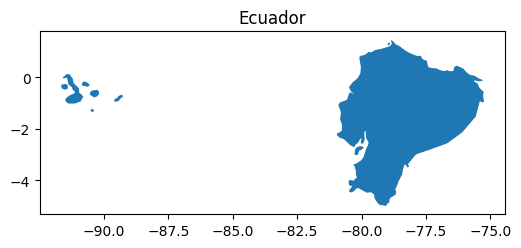

In [4]:
countries = gpd.read_file(COUNTRY_SHAPEFILE)[["ADMIN", "geometry"]].set_index("ADMIN")
country_boundary = countries.loc[[COUNTRY_NAME_IN_SHAPEFILE]]
country_geometry = country_boundary.geometry.iloc[0]

country_boundary.plot(figsize=(6, 6))
plt.title(COUNTRY_NAME_IN_SHAPEFILE)
plt.show()


## Step 5. Load rivers and HydroBASINS features

HydroBASINS level 12 is used for the detailed correction with station observations.

HydroBASINS level 5 is used for the final aggregated map.


In [5]:
def load_hydrobasins_for_country(level, country_geometry):
    level_string = str(level).zfill(2)
    basin_file = HYDROBASINS_FOLDER / f"hybas_lake_sa_lev{level_string}_v1c.shp"
    basins = gpd.read_file(basin_file)

    lakes = basins[basins["LAKE"] == 1].copy()
    basins = basins[basins["LAKE"] == 0].copy()

    country_basins = gpd.clip(basins, country_geometry)
    country_lakes = gpd.clip(lakes, country_geometry)

    return country_basins, country_lakes

rivers = gpd.read_file(HYDRORIVERS_FILE)
country_rivers = gpd.clip(rivers, country_geometry)

# Exclude ORD_FLOW >= 7 means that the points with average river_discharge < 1 m/s are not considered as rivers
country_rivers = country_rivers[country_rivers["ORD_FLOW"] < 7].copy()

country_basins_l12, country_lakes_l12 = load_hydrobasins_for_country(12, country_geometry)
country_basins_l5, country_lakes_l5 = load_hydrobasins_for_country(5, country_geometry)

country_basins_l12["L5basin"] = country_basins_l12["PFAF_ID"].astype(str).str[:5].astype(int)

print("Level 12 basins:", len(country_basins_l12))
print("Level 5 basins:", len(country_basins_l5))
print("Rivers:", len(country_rivers))


Level 12 basins: 2110
Level 5 basins: 11
Rivers: 15287


## Step 6. Load basin statistics from the previous notebook

The previous notebook should have produced one CSV per month at level 12, named like:

`river_discharge_l12_ecuador_m12.csv`

If `ANNUAL_PLOT = True`, the notebook loads all twelve monthly CSV files and computes their average.


In [6]:
def read_l12_basin_statistics_for_month(month):
    input_file = BASIN_STATISTICS_FOLDER / f"river_discharge_l12_{COUNTRY_FOLDER}_m{month}.csv"
    df = pd.read_csv(input_file)

    if "Unnamed: 0" in df.columns:
        df = df.drop(columns="Unnamed: 0")

    df["geometry"] = gpd.GeoSeries.from_wkt(df["geometry"])
    gdf = gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326")

    return gdf

if ANNUAL_PLOT:
    monthly_files = []

    for month in range(1, 2):
        monthly_gdf = read_l12_basin_statistics_for_month(month)
        monthly_gdf = monthly_gdf.rename(
            columns={"mean_river_discharge": f"river_discharge_m{month}"}
        )
        monthly_files.append(monthly_gdf)

    gdf_l12 = monthly_files[0].copy().drop(columns="river_discharge_m1")
    monthly_columns = [monthly_files[i][f"river_discharge_m{i + 1}"] for i in range(2)]
    gdf_l12["mean_river_discharge"] = pd.concat(monthly_columns, axis=1).mean(axis=1)
else:
    gdf_l12 = read_l12_basin_statistics_for_month(MONTH)

print(gdf_l12.head())
print("Number of level 12 basins with data:", len(gdf_l12))


     HYBAS_ID   NEXT_DOWN   NEXT_SINK    MAIN_BAS  DIST_SINK  DIST_MAIN  \
0  6120032930           0  6120032930  6120032930        0.0        0.0   
1  6121051620  6120230300  6120007000  6120007000     4694.3     4694.3   
2  6120230480  6121052540  6120007000  6120007000     4673.4     4673.4   
3  6121052302  6121052301  6120032970  6120032970       85.4       85.4   
4  6120230211  6129504941  6120007000  6120007000     4278.6     4278.6   

   SUB_AREA  UP_AREA       PFAF_ID SIDE  LAKE  ENDO  COAST  ORDER    SORT  \
0     217.8    217.8  672030393010    M     0     0      1      0  138120   
1     129.2    129.2  622986860200    M     0     0      0      5   65188   
2      12.0   2018.8  622986850000    M     0     0      0      4   65076   
3      56.6    173.4  672030409200    R     0     0      0      1  138140   
4      54.1   3221.2  622978973000    L     0     0      0      2   62407   

                                            geometry  mean_river_discharge  
0  POLYGO

## Step 7. Load station observations

The station CSV is expected to contain at least these columns:

`id`, `month`, `latitude`, `longitude`, `river_discharge`

For monthly maps, only the selected month is used. For annual maps, station values are averaged by station id.


In [7]:
STATIONS_FILE = STATIONS_FOLDER / f"allstats_river_discharge_{COUNTRY_FOLDER}.csv"

stations_data = pd.read_csv(STATIONS_FILE)

if ANNUAL_PLOT:
    stations_selected = (
        stations_data
        .groupby("id", as_index=False)
        .mean(numeric_only=True)
    )
else:
    stations_selected = stations_data[stations_data["month"] == MONTH].copy()

stations_gdf = gpd.GeoDataFrame(
    stations_selected,
    geometry=gpd.points_from_xy(stations_selected["longitude"], stations_selected["latitude"]),
    crs="EPSG:4326"
)
stations_gdf = stations_gdf.to_crs(gdf_l12.crs)

print("Stations used:", len(stations_gdf))
stations_gdf.head()


Stations used: 24


,id,month,river_discharge,name,latitude,longitude,altitude,geometry
0,H0011,1,175.314783,MIRA EN LITA,0.84917,-78.46361,475,POINT (-78.46361 0.84917)
12,H0016,1,7.376960,APAQUI AJ CHOTA,0.44639,-77.93417,1715,POINT (-77.93417 0.44639)
24,H0091,1,1.642200,GRANDE AJ JATIVA,0.80417,-77.84611,3120,POINT (-77.84611 0.80417)
36,H0159,1,4.549004,SAN PEDRO EN MACHACHI,-0.46194,-78.54500,2680,POINT (-78.54500 -0.46194)
48,H0166,1,19.373147,TOACHI EN LAS PAMPAS,-0.43667,-78.98194,1110,POINT (-78.98194 -0.43667)


## Step 8. Integrate station observations into level 12 basins

For each HydroBASINS level 12 polygon that contains one or more stations, the river discharge is corrected using a weighted average between the station observation and the original basin statistic.

The formula is:

$$Q_{integrated} = w \cdot Q_{station} + (1 - w) \cdot Q_{basin}$$

Use a higher `STATION_WEIGHT` when stations should have more influence. Use a lower value when the basin statistics should remain dominant.


In [8]:
STATION_WEIGHT = 0.4


def integrate_station_observations(stations_gdf, basins_gdf, station_weight):
    joined = gpd.sjoin(
        stations_gdf,
        basins_gdf[["HYBAS_ID", "mean_river_discharge", "geometry"]],
        how="left",
        predicate="within"
    )

    station_values = (
        joined
        .groupby("HYBAS_ID")["river_discharge"]
        .mean()
        .reset_index()
    )

    integrated = basins_gdf.merge(station_values, on="HYBAS_ID", how="left")
    integrated["mean_river_discharge_integrated"] = integrated["mean_river_discharge"]

    mask = integrated["river_discharge"].notna()

    integrated.loc[mask, "mean_river_discharge_integrated"] = (
        station_weight * integrated.loc[mask, "river_discharge"]
        + (1 - station_weight) * integrated.loc[mask, "mean_river_discharge"]
    )

    return integrated

gdf_l12_integrated = integrate_station_observations(
    stations_gdf=stations_gdf,
    basins_gdf=gdf_l12,
    station_weight=STATION_WEIGHT
)

print("Basins corrected with stations:", gdf_l12_integrated["river_discharge"].notna().sum())
gdf_l12_integrated.head()


Basins corrected with stations: 24


,HYBAS_ID,NEXT_DOWN,NEXT_SINK,MAIN_BAS,DIST_SINK,DIST_MAIN,SUB_AREA,UP_AREA,PFAF_ID,SIDE,LAKE,ENDO,COAST,ORDER,SORT,geometry,mean_river_discharge,river_discharge,mean_river_discharge_integrated
0,6120032930,0,6120032930,6120032930,0.0,0.0,217.8,217.8,672030393010,M,0,0,1,0,138120,"POLYGON ((-80.82874 -1.23226, -80.85033 -1.209...",1.199093,NaN,1.199093
1,6121051620,6120230300,6120007000,6120007000,4694.3,4694.3,129.2,129.2,622986860200,M,0,0,0,5,65188,"POLYGON ((-78.81891 -1.11197, -78.82707 -1.104...",2.523690,NaN,2.523690
2,6120230480,6121052540,6120007000,6120007000,4673.4,4673.4,12.0,2018.8,622986850000,M,0,0,0,4,65076,"POLYGON ((-78.60896 -1.06341, -78.61250 -1.062...",53.523438,7.437395,35.089020
3,6121052302,6121052301,6120032970,6120032970,85.4,85.4,56.6,173.4,672030409200,R,0,0,0,1,138140,"POLYGON ((-80.15221 -1.10057, -80.15280 -1.101...",NaN,NaN,NaN
4,6120230211,6129504941,6120007000,6120007000,4278.6,4278.6,54.1,3221.2,622978973000,L,0,0,0,2,62407,"POLYGON ((-77.81158 -1.06725, -77.81307 -1.073...",212.947388,NaN,212.947388


## Step 9. Define a reusable plotting function

This function creates a map of river discharge for the selected basin layer.

For Ecuador, the function includes an optional inset for Galápagos. For other countries, set `ADD_GALAPAGOS_INSET = False`.


In [9]:
ADD_GALAPAGOS_INSET = COUNTRY_FOLDER.lower() == "ecuador"


def plot_river_discharge_map(
    basins_gdf,
    value_column,
    rivers_gdf,
    lakes_gdf,
    ticks,
    norm,
    title,
    output_file,
    add_galapagos_inset=False
):
    fig, ax = plt.subplots(
        nrows=1,
        ncols=1,
        figsize=(12, 10),
        subplot_kw={"projection": ccrs.PlateCarree()}
    )

    basins_gdf.plot(
        column=value_column,
        ax=ax,
        cmap="Blues",
        legend=False,
        norm=norm,
        edgecolor="k",
        linewidth=0.5
    )

    main_rivers = rivers_gdf[rivers_gdf["ORD_FLOW"] < 6]
    main_rivers.plot(
        ax=ax,
        color="orange",
        linewidth=3 / main_rivers["ORD_FLOW"]
    )

    if len(lakes_gdf) > 0:
        lakes_gdf.plot(ax=ax, facecolor="green", edgecolor="none", zorder=10)

    ax.coastlines(linewidth=0.5)

    minx, miny, maxx, maxy = country_boundary.total_bounds
    padding_x = (maxx - minx) * 0.05
    padding_y = (maxy - miny) * 0.05
    ax.set_extent(
        [minx - padding_x, maxx + padding_x, miny - padding_y, maxy + padding_y],
        crs=ccrs.PlateCarree()
    )

    ax.set_title(title, fontsize=22)

    gridlines = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=0.5,
        color="black",
        alpha=0.5,
        linestyle="--"
    )
    gridlines.top_labels = False
    gridlines.right_labels = False
    gridlines.xlabel_style = {"size": 14}
    gridlines.ylabel_style = {"size": 14}
    
    if add_galapagos_inset:
        main_pos = ax.get_position()
            
        inset_left = main_pos.x0 + main_pos.width * 0.18
        inset_bottom = main_pos.y0 + main_pos.height * 0.22
        
        inset_width = main_pos.width * 0.25
        inset_height = main_pos.height * 0.22
    
        inset_ax = fig.add_axes(
            [inset_left, inset_bottom, inset_width, inset_height],
            projection=ccrs.PlateCarree()
        )
    
        basins_gdf.plot(
            column=value_column,
            ax=inset_ax,
            cmap="Blues",
            legend=False,
            norm=norm,
            edgecolor="k",
            linewidth=0.5
        )
    
        inset_ax.coastlines(linewidth=0.4)
        inset_ax.set_extent([-92.2, -89.0, -1.7, 0.8], crs=ccrs.PlateCarree())
        inset_ax.set_title("Galápagos", fontsize=14)
    
        inset_ax.gridlines(
            crs=ccrs.PlateCarree(),
            draw_labels=False,
            linewidth=0.3,
            color="black",
            alpha=0.4,
            linestyle="--"
        )

    colorbar_object = plt.cm.ScalarMappable(norm=norm, cmap="Blues")
    colorbar = fig.colorbar(colorbar_object, ax=ax, orientation="vertical", aspect=25, shrink=0.75)
    colorbar.set_ticks(ticks)
    colorbar.set_ticklabels(ticks)
    colorbar.set_label("", size=16)
    colorbar.ax.tick_params(labelsize=14)

    plt.savefig(output_file, dpi=150, bbox_inches="tight")
    #plt.close(fig)

    return fig


## Step 10. Plot and save the integrated level 12 map

The map shows station corrected river discharge at the highest HydroBASINS resolution used in this workflow.


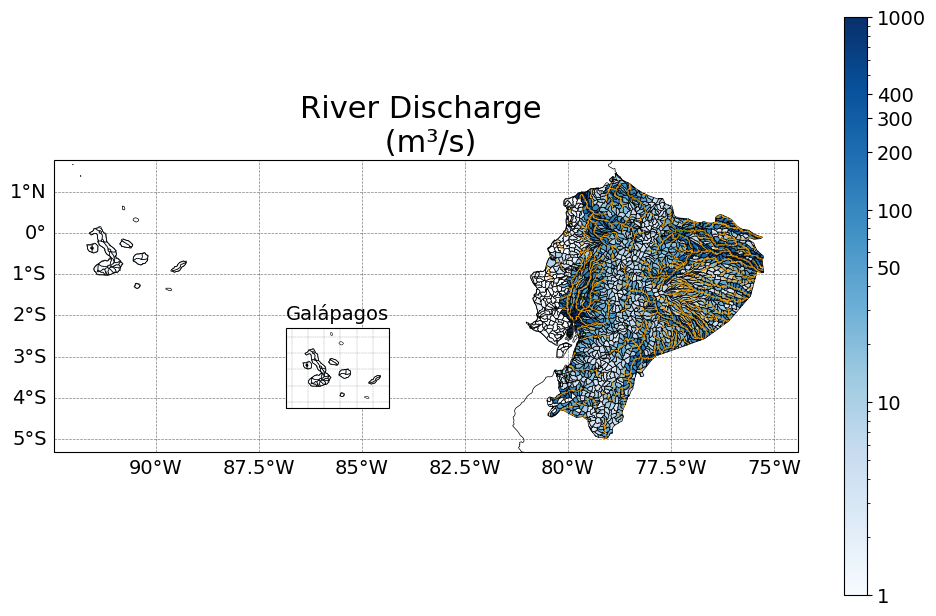

In [10]:
L12_VALUE_COLUMN = "mean_river_discharge_integrated"
gdf_l12_integrated[L12_VALUE_COLUMN] = gdf_l12_integrated[L12_VALUE_COLUMN].fillna(1)

l12_norm = colors.LogNorm(vmin=1, vmax=1000)
l12_ticks = [1, 10, 50, 100, 200, 300, 400, 1000]

fig = plot_river_discharge_map(
    basins_gdf=gdf_l12_integrated,
    value_column=L12_VALUE_COLUMN,
    rivers_gdf=country_rivers,
    lakes_gdf=country_lakes_l12,
    ticks=l12_ticks,
    norm=l12_norm,
    title=f"River Discharge \n (m³/s)",
    output_file=L12_FIGURE_FILE,
    add_galapagos_inset=ADD_GALAPAGOS_INSET
)


## Step 11. Save the integrated level 12 dataset

The output keeps the corrected value in `mean_river_discharge_integrated`.


In [11]:
if ANNUAL_PLOT:
    l12_output_file = OUTPUT_FOLDER / f"river_discharge_l12_{COUNTRY_FOLDER}_annual_integrated.csv"
else:
    l12_output_file = OUTPUT_FOLDER / f"river_discharge_l12_{COUNTRY_FOLDER}_m{MONTH}_integrated.csv"

columns_to_drop = [column for column in ["river_discharge"] if column in gdf_l12_integrated.columns]
gdf_l12_output = gdf_l12_integrated.drop(columns=columns_to_drop)
gdf_l12_output.to_csv(l12_output_file, index=False)

print("Saved:", l12_output_file)


Saved: ../data/atlas_data/ecuador/river_discharge_l12_ecuador_m1_integrated.csv


## Step 12. Aggregate the integrated values to HydroBASINS level 5

The aggregation uses the level 12 basin area as weight. This produces one integrated discharge value for each level 5 basin.


In [12]:
def aggregate_to_lower_basin_level(high_resolution_gdf, low_resolution_basins):
    high_resolution_gdf = high_resolution_gdf.to_crs(low_resolution_basins.crs)

    high_resolution_points = high_resolution_gdf.copy()
    high_resolution_points["geometry"] = high_resolution_points.geometry.representative_point()

    joined = gpd.sjoin(
        high_resolution_points,
        low_resolution_basins[["HYBAS_ID", "geometry"]],
        how="left",
        predicate="within"
    )

    joined["weighted_discharge"] = (
        joined["mean_river_discharge_integrated"] * joined["SUB_AREA"]
    )

    aggregated = (
        joined
        .groupby("HYBAS_ID_right")
        .agg(
            weighted_discharge=("weighted_discharge", "sum"),
            area=("SUB_AREA", "sum")
        )
        .reset_index()
    )

    aggregated["mean_river_discharge_integrated"] = (
        aggregated["weighted_discharge"] / aggregated["area"]
    )

    aggregated = aggregated.rename(columns={"HYBAS_ID_right": "HYBAS_ID"})

    output_gdf = low_resolution_basins.merge(
        aggregated[["HYBAS_ID", "mean_river_discharge_integrated"]],
        on="HYBAS_ID",
        how="left"
    )

    return output_gdf

gdf_l5_integrated = aggregate_to_lower_basin_level(gdf_l12_integrated, country_basins_l5)
print("Level 5 basins:", len(gdf_l5_integrated))
gdf_l5_integrated.head()


Level 5 basins: 11


,HYBAS_ID,NEXT_DOWN,NEXT_SINK,MAIN_BAS,DIST_SINK,DIST_MAIN,SUB_AREA,UP_AREA,PFAF_ID,SIDE,LAKE,ENDO,COAST,ORDER,SORT,geometry,mean_river_discharge_integrated
0,6050315910,6050266740,6050007000,6050007000,3493.7,3493.7,364869.2,364873.4,62298,M,0,0,0,2,178,"POLYGON ((-79.39640 -4.83971, -79.39583 -4.837...",49.281872
1,6050032100,0,6050032100,6050032100,0.0,0.0,17761.9,17761.9,67108,M,0,0,0,1,516,"MULTIPOLYGON (((-79.33715 -4.54826, -79.33369 ...",25.349405
2,6050032110,0,6050032110,6050032110,0.0,0.0,11236.5,11236.5,67109,M,0,0,1,0,517,"POLYGON ((-79.45085 -3.55502, -79.45000 -3.558...",54.172108
3,6050032290,0,6050032290,6050032290,0.0,0.0,16478.7,16478.7,67201,M,0,0,1,0,518,"MULTIPOLYGON (((-79.80355 -2.38433, -79.80594 ...",29.480832
4,6050266740,6050287820,6050007000,6050007000,2156.8,2156.8,514725.6,1233304.8,62297,M,0,0,0,1,165,"POLYGON ((-75.83245 -1.82012, -75.83390 -1.814...",132.360442


## Step 13. Plot and save the integrated level 5 map


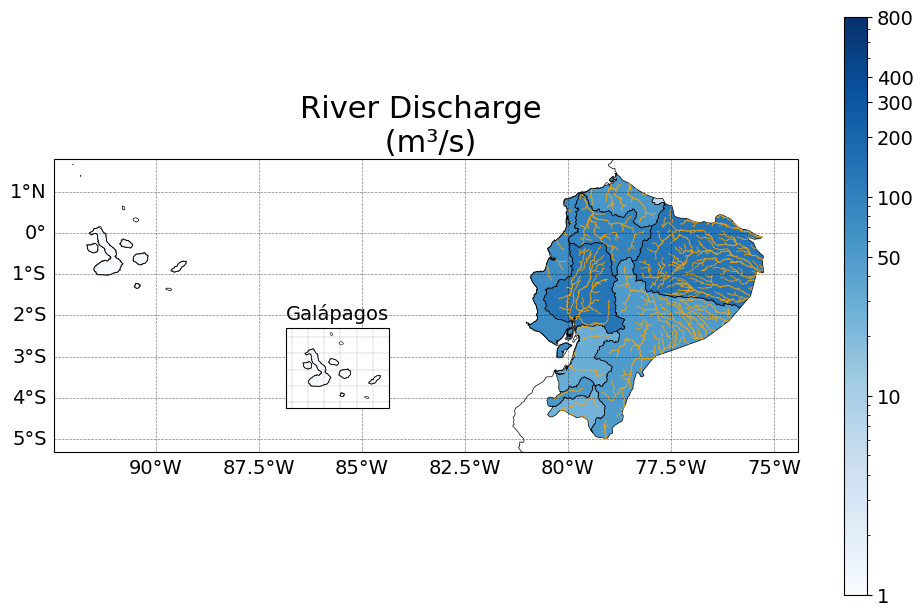

In [13]:
L5_VALUE_COLUMN = "mean_river_discharge_integrated"
gdf_l5_integrated[L5_VALUE_COLUMN] = gdf_l5_integrated[L5_VALUE_COLUMN].fillna(1)

l5_norm = colors.LogNorm(vmin=1, vmax=800)
l5_ticks = [1, 10, 50, 100, 200, 300, 400, 800]

fig = plot_river_discharge_map(
    basins_gdf=gdf_l5_integrated,
    value_column=L5_VALUE_COLUMN,
    rivers_gdf=country_rivers,
    lakes_gdf=country_lakes_l5,
    ticks=l5_ticks,
    norm=l5_norm,
    title=f"River Discharge \n (m³/s)",
    output_file=L5_FIGURE_FILE,
    add_galapagos_inset=ADD_GALAPAGOS_INSET
)


## Step 14. Save the integrated level 5 GeoJSON

This file can be opened directly in GIS software.


In [14]:
if ANNUAL_PLOT:
    l5_output_file = OUTPUT_FOLDER / f"river_discharge_l5_{COUNTRY_FOLDER}_annual_integrated.geojson"
else:
    l5_output_file = OUTPUT_FOLDER / f"river_discharge_l5_{COUNTRY_FOLDER}_m{MONTH}_integrated.geojson"

gdf_l5_integrated.to_file(l5_output_file, driver="GeoJSON")

print("Saved:", l5_output_file)


Saved: ../data/atlas_data/ecuador/river_discharge_l5_ecuador_m1_integrated.geojson


## Step 15. Optional quality check: inspect one level 5 basin

This section plots the level 12 subbasins inside one selected level 5 basin. It is useful for checking whether the integration and aggregation look spatially consistent.


In [15]:
SELECTED_L5_BASIN_INDEX = 1

selected_l5_basin = gpd.GeoDataFrame(country_basins_l5.iloc[[SELECTED_L5_BASIN_INDEX]])
selected_l5_pfaf = selected_l5_basin["PFAF_ID"].iloc[0]

selected_l12_basins = country_basins_l12[country_basins_l12["L5basin"] == selected_l5_pfaf]
selected_rivers = gpd.clip(country_rivers, selected_l5_basin)

gdf_l12_integrated["L5basin"] = gdf_l12_integrated["PFAF_ID"].astype(str).str[:5].astype(int)
selected_l12_integrated = gdf_l12_integrated[gdf_l12_integrated["L5basin"] == selected_l5_pfaf].copy()
selected_l12_integrated[L12_VALUE_COLUMN] = selected_l12_integrated[L12_VALUE_COLUMN].fillna(1)

print("Selected level 5 PFAF ID:", selected_l5_pfaf)
print("Level 12 subbasins inside selected basin:", len(selected_l12_integrated))


Selected level 5 PFAF ID: 67108
Level 12 subbasins inside selected basin: 68


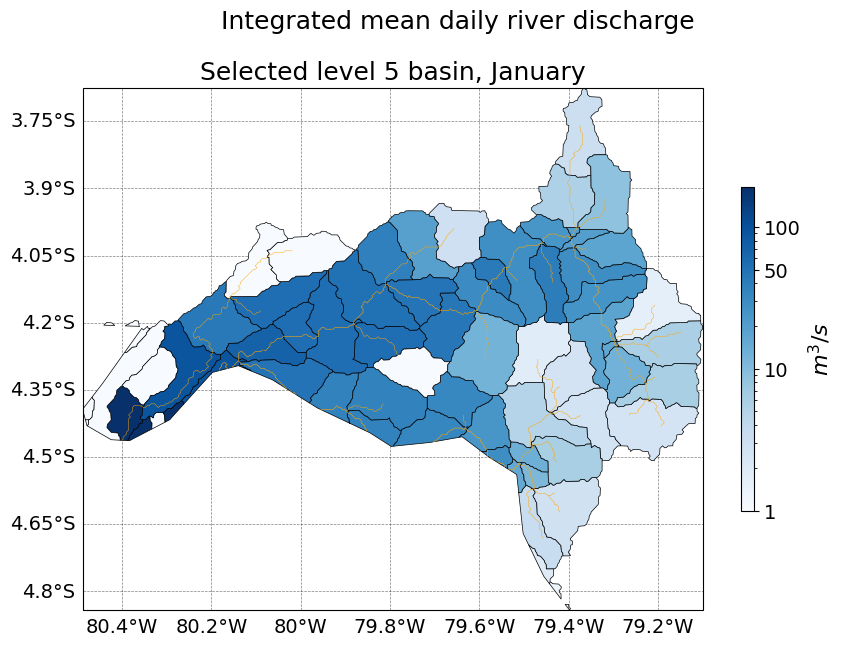

In [16]:
basin_bounds = selected_l5_basin.total_bounds
maximum_value = max(selected_l12_integrated[L12_VALUE_COLUMN].max(), 1)

single_basin_norm = colors.LogNorm(vmin=1, vmax=maximum_value)
single_basin_ticks = [tick for tick in [1, 10, 50, 100, 200, 300, 400, 800, 1500] if tick <= maximum_value]
if len(single_basin_ticks) == 0:
    single_basin_ticks = [1]

fig, ax = plt.subplots(
    1,
    1,
    figsize=(10, 7),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

ax.set_extent(
    [basin_bounds[0], basin_bounds[2], basin_bounds[1], basin_bounds[3]],
    crs=ccrs.PlateCarree()
)

ax.coastlines(linewidth=0.5)

gridlines = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.5,
    color="black",
    alpha=0.5,
    linestyle="--"
)
gridlines.top_labels = False
gridlines.right_labels = False
gridlines.xformatter = LONGITUDE_FORMATTER
gridlines.yformatter = LATITUDE_FORMATTER
gridlines.xlabel_style = {"size": 14}
gridlines.ylabel_style = {"size": 14}

if len(selected_rivers) > 0:
    selected_rivers.plot(
        ax=ax,
        color="orange",
        linewidth=2 / selected_rivers["ORD_FLOW"],
        zorder=3
    )

if len(country_lakes_l5) > 0:
    country_lakes_l5.plot(
        ax=ax,
        facecolor="grey",
        edgecolor="none",
        zorder=4
    )

selected_l12_integrated.plot(
    column=L12_VALUE_COLUMN,
    ax=ax,
    cmap="Blues",
    legend=False,
    norm=single_basin_norm,
    edgecolor="k",
    linewidth=0.5,
    zorder=2
)

ax.set_title(f"Selected level 5 basin, {PERIOD_LABEL}", fontsize=18)
plt.suptitle("Integrated mean daily river discharge", fontsize=18)

colorbar_object = plt.cm.ScalarMappable(norm=single_basin_norm, cmap="Blues")
colorbar_object.set_array(np.array([1]))
colorbar = fig.colorbar(colorbar_object, ax=ax, orientation="vertical", shrink=0.6, aspect=25)
colorbar.set_ticks(single_basin_ticks)
colorbar.set_ticklabels(single_basin_ticks)
colorbar.set_label(r"$m^3/s$", size=16)
colorbar.ax.tick_params(labelsize=14)

plt.show()


## Notes for reuse

To run the notebook for another country, update only Step 2 unless the country uses a different HydroBASINS or HydroRIVERS continent file.

For Ecuador, keep `ADD_GALAPAGOS_INSET = True`. For most other countries, it should be `False`.

The main final outputs are the integrated level 12 CSV, the integrated level 5 GeoJSON and the two PNG maps.
